# The Toolkit, End to End

## Demonstrates every tool in the library and when to reach for it:
- Testing a metric while the data is still arriving, with no fixed sample size
- The four metric shapes you actually have: averages, rates, spread, percentiles
- Reading the result object and the history table
- How hard to bet: the three staking rules, and what each costs you
- The five engines under the hood, and which one matches your data
- Converting to and from p-values for people who want p-values
- Estimating how long a test will take before you run it
- Running hundreds of thousands of tests at once on the Rust engine
- Deciding which of them are real: three corrections, plus the versions whose
  decisions never get taken back
- Collapsing many tests into one number, five different ways, and the rules for each
- Comparing more than two groups without inventing a post-hoc correction
- Comparing medians instead of averages
- Plugging in your own bet
- Nulls that are a range rather than a single number
- Checking a model you can differentiate but cannot normalise
- What is not finished yet, stated plainly
- A cheat sheet mapping jobs to tools

Everything here answers one question: **can I stop and act now?** Classical tests
answer a different one - "if I had committed to exactly this sample size in advance,
would the result be significant?" - and the gap between those two questions is why
teams that peek at dashboards get burned. Every tool below is safe to look at
whenever you like, as often as you like, and to stop on whenever you want.

The single idea underneath: a test is a **bet against the null hypothesis**. You start
with 1 dollar. Each new observation you place a fair bet - fair *if the null is true*.
If the null is false, the bets pay, and your capital grows. Your capital is the
evidence. If it ever reaches 20, you have a result at the 5% level, because a fair
game cannot make you 20x rich more than 5% of the time. That is the whole framework.

References (for the parts where the construction matters):
    Ramdas & Wang (2025). Hypothesis testing with e-values - the standard reference
    for everything in this notebook.
    Howard, Ramdas, McAuliffe & Sekhon (2021). Time-uniform, nonasymptotic,
    nonparametric confidence sequences - the mixture martingales and boundaries.
    Waudby-Smith & Ramdas (2024). Estimating means of bounded random variables by
    betting - the adaptive staking rule.
    Vovk & Wang (2021, 2024). E-values and merging e-values - the merging functions.
    Turner, Ly & Grunwald (2022) (k-sample), Larsson, Ramdas & Ruf (2025)
    (set-valued nulls), Martinez-Taboada & Ramdas (2025) (score-only testing).

In [1]:
import warnings

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from expectation.seqtest.sequential_e_testing import SequentialTesting
from expectation.modules.hypothesistesting import (
    EProcess,
    EProcessConfig,
    BettingStrategy,
)
from expectation.modules.eprocessupdater import EProcessUpdater
from expectation.modules.calibrators import EToPCalibrator, PToECalibrator, PToECalibratorType
from expectation.modules.epower import EPowerCalculator, EPowerConfig
from expectation.modules.martingales import (
    TwoSidedNormalMixture,
    OneSidedNormalMixture,
    GammaExponentialMixture,
    GammaPoissonMixture,
    BetaBinomialMixture,
)
from expectation.modules.merging import MergingConfig, MergingFunction, create_merger
from expectation.modules.adjusters import LookbackAdjuster, SqrtAdjuster
from expectation.modules.orderstatistics import StaticOrderStatistics
from expectation.modules.quantiletest import QuantileABTest
from expectation.par_seqtest import ParallelSequentialTest, ParallelTestConfig
from expectation.ksample.ksample_test import KSampleSequentialTest
from expectation.ksample.config import KSampleConfig, KSampleAlternativeType

ALPHA = 0.05
print(f"Evidence needed to act at the {ALPHA:.0%} level: capital >= {1 / ALPHA:.0f}x")

Evidence needed to act at the 5% level: capital >= 20x


# 1. The One-Liner: Test a Metric While the Data Is Still Arriving

**The job:** you changed something. Is the metric different from what it was?

`SequentialTesting` takes the metric type, the number you are testing against, and the
direction you care about. Then you feed it data whenever data shows up - one row, a
thousand rows, hourly batches, whatever your pipeline produces - and after every batch
it tells you whether you can act yet.

There is no sample-size calculation to commit to and no penalty for checking often.
The thing to watch is `e_process`, the running capital. When it crosses 20 you have a
result at the 5% level.

In [2]:
rng = np.random.default_rng(0)

# Reality: the new version is genuinely 0.3 standard deviations better.
truth = rng.normal(0.30, 1.0, 1200)

test = SequentialTesting(test_type="mean", null_value=0.0, alternative="two_sided")

for i in range(0, 1200, 25):           # a batch every 25 observations
    result = test.update(truth[i:i + 25])
    if result.reject_null:
        print(f"Actionable after {result.sample_size} observations")
        print(f"  capital        : {result.e_process.cumulative_value:,.1f}x  "
              f"(needed {1 / ALPHA:.0f}x)")
        print(f"  p-value        : {result.p_value:.4f}")
        print(f"  evidence/obs   : {result.e_power:.3f}")
        break
else:
    print(f"Not actionable after {result.sample_size} observations "
          f"(capital {result.e_process.cumulative_value:.2f}x)")

Actionable after 75 observations
  capital        : 48.6x  (needed 20x)
  p-value        : 0.0206
  evidence/obs   : 1.295


# 2. The Four Metric Shapes You Actually Have

Nearly every business metric is one of four things, and the same object handles all of
them - you change one string.

| `test_type` | What it tests | Typical metric |
|---|---|---|
| `"mean"` | an average | revenue per user, latency, basket size |
| `"proportion"` | a rate | conversion, click-through, error rate, churn |
| `"variance"` | spread | latency consistency, quality control, risk |
| `"quantile"` | a percentile | p95 latency, median order value |

The percentile one matters more than people expect. If your SLA is about p95 latency,
testing the *average* latency answers a question nobody asked - a change that fixes the
tail while raising the mean looks like a regression on the average and a win on the SLA.

In [3]:
rng = np.random.default_rng(7)

jobs = [
    ("mean",       0.0,  {},                 rng.normal(0.30, 1.0, 1200),
     "revenue per user moved"),
    ("proportion", 0.50, {},                 rng.binomial(1, 0.57, 1200).astype(float),
     "conversion rate is not 50%"),
    ("variance",   1.0,  {},                 rng.normal(0.0, 1.35, 1200),
     "latency got less consistent"),
    ("quantile",   0.0,  {"quantile": 0.5},  rng.normal(0.35, 1.0, 1200),
     "the median moved"),
]

rows = []
for test_type, null_value, extra, data, question in jobs:
    t = SequentialTesting(test_type=test_type, null_value=null_value,
                          alternative="two_sided", **extra)
    stop, seen = None, 0
    for i in range(0, len(data), 25):
        r = t.update(data[i:i + 25])
        seen += 25
        if r.reject_null:
            stop = seen
            break
    rows.append({
        "question": question,
        "test_type": test_type,
        "observations needed": stop if stop else f">{seen}",
        "capital": round(r.e_process.cumulative_value, 1),
        "p-value": round(r.p_value, 5) if r.p_value else None,
    })

print(pd.DataFrame(rows).to_string(index=False))

# A detection is worthless until you know the tool does not fire on a null.
print("\nSame four lenses, run against data where the null is TRUE:")
print(f"{'lens':>14} {'false-alarm rate':>18} {'usable?':>10}")
for label, null_value, extra, test_type in [
    ("mean", 0.0, {}, "mean"),
    ("proportion", 0.5, {}, "proportion"),
    ("variance", 1.0, {}, "variance"),
    ("quantile p50", 0.0, {"quantile": 0.5}, "quantile"),
]:
    false_alarms = 0
    for replication in range(100):
        rng_c = np.random.default_rng(2000 + replication)
        t = SequentialTesting(test_type=test_type, null_value=null_value,
                              alternative="greater", **extra)
        draws = (rng_c.binomial(1, 0.5, 3000).astype(float) if test_type == "proportion"
                 else rng_c.normal(0.0, 1.0, 3000))
        for i in range(0, 3000, 100):
            if t.update(draws[i:i + 100]).reject_null:
                false_alarms += 1
                break
    rate = false_alarms / 100
    print(f"{label:>14} {rate:18.0%} {('yes' if rate <= 0.10 else 'NO'):>10}")

print()
print("The variance path fires on every run of pure noise. It is a known defect in")
print("this library (SEQ-02 in its own audit), so the 'detection' in the table above")
print("means nothing - do not use test_type='variance' for a decision yet. See")
print("section 17 for the full list of what is not finished.")

                   question  test_type  observations needed  capital  p-value
     revenue per user moved       mean                  350     52.4  0.01909
 conversion rate is not 50% proportion                  425     38.6  0.02591
latency got less consistent   variance                   25    102.2  0.00978
           the median moved   quantile                  125     27.5  0.03631

Same four lenses, run against data where the null is TRUE:
          lens   false-alarm rate    usable?


          mean                 0%        yes


    proportion                 3%        yes
      variance               100%         NO


  quantile p50                 1%        yes

The variance path fires on every run of pure noise. It is a known defect in
this library (SEQ-02 in its own audit), so the 'detection' in the table above
means nothing - do not use test_type='variance' for a decision yet. See
section 17 for the full list of what is not finished.


# 3. What Comes Back, and What Every Field Means

`update()` returns a result object; the test also keeps a full history you can hand
straight to a dashboard. The two fields that matter operationally:

- **`e_process.cumulative_value`** - your capital. This *is* the evidence. 20x means a
  result at the 5% level, 100x is strong, 2x is nothing. It is a number a
  non-statistician can reason about: "we turned 1 dollar into 34".
- **`p_value`** - 1 divided by the best capital you ever reached. Provided because
  stakeholders ask for it. It is valid at every single row, unlike the p-value from a
  fixed-horizon test, which is only valid at one pre-committed sample size.

`confidence_lower` / `confidence_upper` give a running interval for the quantity, valid
at every row simultaneously - that is the number to put in the decision memo, because
it survives having been looked at fifty times.

columns: ['step', 'observations', 'e_value', 'cumulative_e_value', 'reject_null', 'p_value', 'sample_size', 'confidence_lower', 'confidence_upper', 'stopping_time', 'max_e_value', 'timestamp', 'e_power', 'e_power_is_positive', 'optimal_lambda']

 step  sample_size   e_value  cumulative_e_value  p_value  confidence_lower  confidence_upper
    1           25  0.163727            0.163727 1.000000         -0.354715          0.807847
    2           50 69.014309           11.299486 0.088500         -0.019015          0.877008
    3           75  4.303877           48.631597 0.020563          0.028350          0.801592


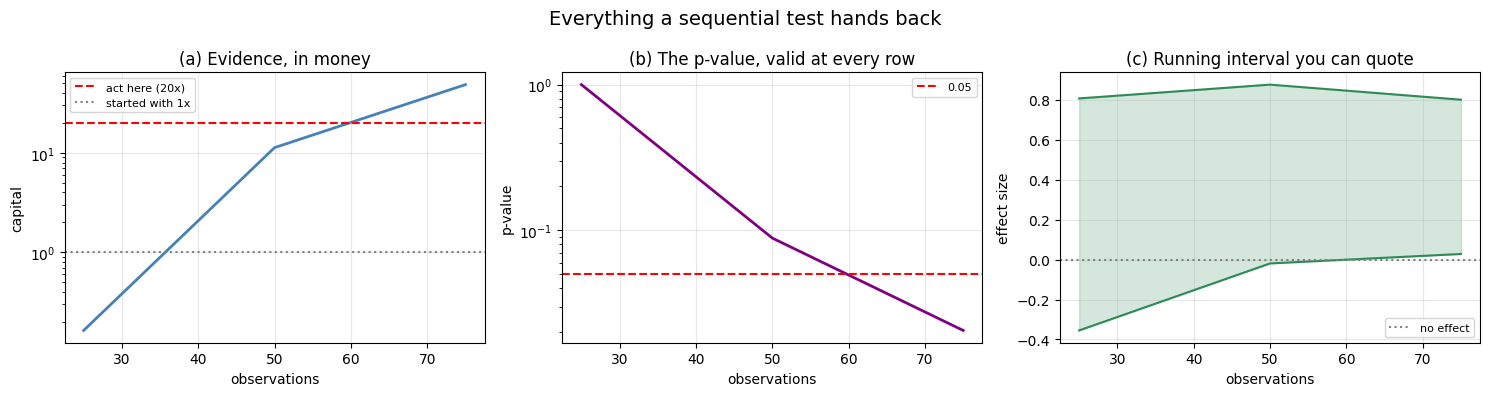

In [4]:
history = test.get_history_df()
print("columns:", list(history.columns))
print()
print(history[['step', 'sample_size', 'e_value', 'cumulative_e_value',
               'p_value', 'confidence_lower', 'confidence_upper']].tail(5).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.plot(history['sample_size'], history['cumulative_e_value'], lw=2, color='steelblue')
ax.axhline(1 / ALPHA, color='red', ls='--', label=f'act here ({1 / ALPHA:.0f}x)')
ax.axhline(1.0, color='grey', ls=':', label='started with 1x')
ax.set_yscale('log'); ax.set_xlabel('observations'); ax.set_ylabel('capital')
ax.set_title('(a) Evidence, in money')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(history['sample_size'], history['p_value'], lw=2, color='purple')
ax.axhline(ALPHA, color='red', ls='--', label='0.05')
ax.set_yscale('log'); ax.set_xlabel('observations'); ax.set_ylabel('p-value')
ax.set_title('(b) The p-value, valid at every row')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(history['sample_size'], history['confidence_lower'], lw=1.5, color='seagreen')
ax.plot(history['sample_size'], history['confidence_upper'], lw=1.5, color='seagreen')
ax.fill_between(history['sample_size'], history['confidence_lower'],
                history['confidence_upper'], alpha=0.2, color='seagreen')
ax.axhline(0.0, color='grey', ls=':', label='no effect')
ax.set_xlabel('observations'); ax.set_ylabel('effect size')
ax.set_title('(c) Running interval you can quote')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Everything a sequential test hands back', fontsize=14)
plt.tight_layout()
plt.show()

# 4. How Hard to Bet

Each round you choose how much of your capital to stake. That choice is the only knob
that matters for speed, and it is a genuine trade-off rather than a free parameter.

- **`ALL_IN`** - stake everything every round. Fastest when the effect is real and
  obvious. Most exposed to an early run of bad luck.
- **`CONSERVATIVE`** - stake a small fixed fraction. Slowest, but the capital curve is
  smooth, which matters if a VP is watching the dashboard daily.
- **`EMPIRICALLY_ADAPTIVE`** - learn the stake from what has happened so far. Starts
  cautious, leans in once the data supports it. **This is the sensible default.**
- **`LOG_OPTIMAL`** - the theoretical best, but you have to supply the expected payoff
  function yourself via `set_log_optimal_expectation`. Use it only when you genuinely
  know your alternative.

None of these affects validity. A bad staking rule costs you time, never correctness.

400 real payoffs, average 1.321 (a fair game averages 1.0)



        staking rule  rounds to act                final capital worst dip
              all_in             34 707,351,732,089,009,602,560x     0.07x
empirically_adaptive             29 475,977,573,011,559,546,880x     0.50x
        conservative             26     554,997,170,925,578,880x     0.62x

LOG_OPTIMAL needs updater.set_log_optimal_expectation(fn) before use;
without it the updater raises rather than silently guessing.


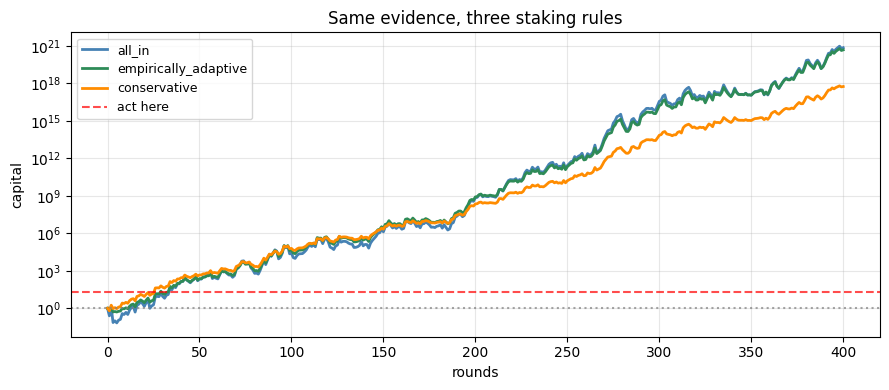

In [5]:
rng = np.random.default_rng(11)

# Use real per-observation evidence rather than invented numbers: run a mean test on a
# small genuine effect and take the payoffs it produced.
pilot = SequentialTesting(test_type="mean", null_value=0.0, alternative="greater")
for chunk in np.array_split(rng.normal(0.15, 1.0, 4000), 400):
    pilot.update(chunk)
e_value_stream = np.array(pilot.e_process.values)
print(f"{len(e_value_stream)} real payoffs, average {e_value_stream.mean():.3f} "
      f"(a fair game averages 1.0)\n")

curves, summary = {}, []
for strategy in (BettingStrategy.ALL_IN, BettingStrategy.EMPIRICALLY_ADAPTIVE,
                 BettingStrategy.CONSERVATIVE):
    config = EProcessConfig(significance_level=ALPHA, betting_strategy=strategy, gamma=1.0)
    process, updater = EProcess(config=config), EProcessUpdater(config)
    for e in e_value_stream:
        updater.update(process, float(e))
    curves[strategy.value] = np.array(process.process_values)
    summary.append({
        "staking rule": strategy.value,
        "rounds to act": updater.get_stopping_time(process),
        "final capital": f"{updater.get_current_value(process):,.0f}x",
        "worst dip": f"{np.min(process.process_values):.2f}x",
    })

print(pd.DataFrame(summary).to_string(index=False))
print()
print("LOG_OPTIMAL needs updater.set_log_optimal_expectation(fn) before use;")
print("without it the updater raises rather than silently guessing.")

fig, ax = plt.subplots(figsize=(9, 4))
for (name, curve), colour in zip(curves.items(), ('steelblue', 'seagreen', 'darkorange')):
    ax.plot(curve, lw=2, color=colour, label=name)
ax.axhline(1 / ALPHA, color='red', ls='--', alpha=0.7, label='act here')
ax.axhline(1.0, color='grey', ls=':', alpha=0.7)
ax.set_yscale('log'); ax.set_xlabel('rounds'); ax.set_ylabel('capital')
ax.set_title('Same evidence, three staking rules')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5. The Engines Under the Hood

`SequentialTesting` picks one of these for you. You only touch them directly if you are
building a custom test - but knowing which is which tells you whether the tool matches
your data, and that is worth two minutes.

| Engine | Use it when your data is | Example |
|---|---|---|
| `TwoSidedNormalMixture` | roughly symmetric, you care about either direction | revenue per user |
| `OneSidedNormalMixture` | same, but only one direction is bad | latency regression |
| `GammaExponentialMixture` | non-negative and skewed, with a bound on the tail | time between failures |
| `GammaPoissonMixture` | counts | support tickets, crashes per hour |
| `BetaBinomialMixture` | yes/no outcomes | conversion, defect rate |

Each takes the same two inputs: `s`, how far the running total has drifted from the
null, and `v`, how much information you have accumulated. Both are tuned by `v_opt` -
the amount of data you expect to need. Getting `v_opt` roughly right makes the test
faster; getting it wrong costs speed, never validity.

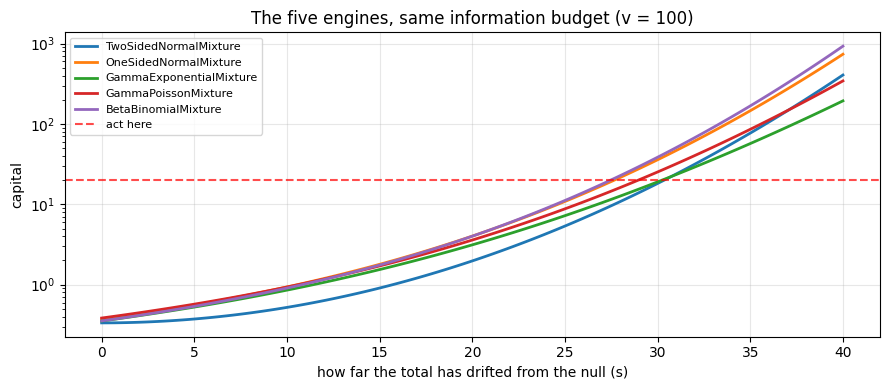

                 engine capital at drift=20 drift needed to act
  TwoSidedNormalMixture               1.98x                68.9
  OneSidedNormalMixture               4.02x                68.6
GammaExponentialMixture               3.13x                82.9
    GammaPoissonMixture               3.59x                75.4
    BetaBinomialMixture               4.02x                65.9


In [6]:
engines = [
    ("TwoSidedNormalMixture", TwoSidedNormalMixture(v_opt=100, alpha_opt=ALPHA)),
    ("OneSidedNormalMixture", OneSidedNormalMixture(v_opt=100, alpha_opt=ALPHA)),
    ("GammaExponentialMixture", GammaExponentialMixture(v_opt=100, alpha_opt=ALPHA, c=1.0)),
    ("GammaPoissonMixture", GammaPoissonMixture(v_opt=100, alpha_opt=ALPHA, c=1.0)),
    ("BetaBinomialMixture", BetaBinomialMixture(v_opt=100, alpha_opt=ALPHA, g=1.0, h=1.0,
                                                is_one_sided=True)),
]

drift_values = np.linspace(0, 40, 120)
fig, ax = plt.subplots(figsize=(9, 4))
rows = []
for name, engine in engines:
    capital = [np.exp(engine.log_superMG(float(s), 100.0)) for s in drift_values]
    ax.plot(drift_values, capital, lw=2, label=name)
    rows.append({
        "engine": name,
        "capital at drift=20": f"{np.exp(engine.log_superMG(20.0, 100.0)):,.2f}x",
        "drift needed to act": f"{engine.bound(100.0, 1 / ALPHA):.1f}",
    })

ax.axhline(1 / ALPHA, color='red', ls='--', alpha=0.7, label='act here')
ax.set_yscale('log'); ax.set_xlabel('how far the total has drifted from the null (s)')
ax.set_ylabel('capital'); ax.set_title('The five engines, same information budget (v = 100)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(pd.DataFrame(rows).to_string(index=False))

# 6. Talking to People Who Want p-values

You will have to. Finance wants a p-value, the regulator's template has a box for it,
and the journal requires one. Both directions are one line.

- **capital to p-value**: `EToPCalibrator` - divide 1 by the best capital you reached.
  Always valid, at every row.
- **p-value to capital**: `PToECalibrator` - five conversion rules. Use this to pull a
  legacy fixed-horizon result into an e-value pipeline, for instance to combine a
  vendor's reported p-value with your own monitoring.

One thing to be honest about: converting a p-value to an e-value loses information and
cannot manufacture the anytime-valid guarantee. If the p-value came from a peeked-at
fixed-horizon test, the e-value you get out inherits that problem.

In [7]:
to_p = EToPCalibrator()
print("capital -> p-value")
for capital in (2.0, 10.0, 20.0, 100.0, 1000.0):
    print(f"  {capital:7,.0f}x  ->  p = {to_p(capital):.4f}")

print("\np-value -> capital (five rules)")
rows = []
for rule in PToECalibratorType:
    converter = PToECalibrator(calibrator_type=rule)
    rows.append({
        "rule": rule.value,
        "p=0.05": round(float(converter(0.05)), 2),
        "p=0.01": round(float(converter(0.01)), 2),
        "p=0.001": round(float(converter(0.001)), 2),
    })
print(pd.DataFrame(rows).to_string(index=False))

capital -> p-value
        2x  ->  p = 0.5000
       10x  ->  p = 0.1000
       20x  ->  p = 0.0500
      100x  ->  p = 0.0100
    1,000x  ->  p = 0.0010

p-value -> capital (five rules)
       rule  p=0.05  p=0.01  p=0.001
      power    2.24    5.00    15.81
    mixture    1.78    4.45    20.79
     linear    1.90    1.98     2.00
     shafer    3.47    9.00    30.62
logarithmic    3.00    4.61     6.91


# 7. How Long Will This Take? (Before You Run It)

The question every stakeholder asks first. `EPowerCalculator` measures evidence per
observation, which converts directly into a time estimate: to reach 20x you need
log(20) = 3 nats of evidence, so

    observations needed  ~  3 / (evidence per observation)

Run it on a pilot, a simulation of the effect you would care about, or last quarter's
data. It is the sequential replacement for a power calculation, and unlike a power
calculation it does not lock you into a sample size - it just sets expectations.

A negative number means your bets are losing money: the alternative you are betting on
is pointing the wrong way. That is a useful alarm on its own.

In [8]:
calculator = EPowerCalculator(EPowerConfig())
rng = np.random.default_rng(3)

print(f"{'effect':>8} {'evidence/obs':>14} {'observations to act':>22}")
for effect in (0.05, 0.10, 0.20, 0.40):
    pilot = SequentialTesting(test_type="mean", null_value=0.0, alternative="greater")
    sample = rng.normal(effect, 1.0, 4000)
    for i in range(0, 4000, 50):
        pilot.update(sample[i:i + 50])
    per_step = np.array(pilot.e_process.values)
    power = calculator.compute(per_step)
    rate = power.e_power / 50                   # per observation, not per batch
    needed = np.log(1 / ALPHA) / rate if rate > 0 else np.inf
    print(f"{effect:8.2f} {rate:14.5f} {needed:22,.0f}")

print()
print("Halving the effect roughly quadruples the data you need - the same brutal")
print("arithmetic as a classical power calculation, just without the commitment.")

  effect   evidence/obs    observations to act
    0.05        0.00085                  3,518
    0.10        0.00327                    916
    0.20        0.02024                    148
    0.40        0.08686                     34

Halving the effect roughly quadruples the data you need - the same brutal
arithmetic as a classical power calculation, just without the commitment.


# 8. Hundreds of Thousands of Tests at Once

One test per metric per segment per region adds up fast: 2,000 features, 20,000
merchants, 300,000 voxels. `ParallelSequentialTest` runs all of them in a Rust engine
with one Python call per time step, so the per-step cost is microseconds rather than
minutes.

You hand it one array of observations - one value per test - and it advances every test
in lock step. Everything the engine knows is available as arrays: capital, p-values,
stopping times, current stake.

In [9]:
import time

K = 50_000
rng = np.random.default_rng(4)

engine = ParallelSequentialTest(
    config=ParallelTestConfig(n_tests=K, alpha=ALPHA, alternative="greater",
                              combiner="all_in"),
    null_values=0.0,
    variance=1.0,
)

# Reality: about 1 test in 1,000 has a real effect; sizes vary; nothing is told to the engine.
is_real = rng.random(K) < 0.001
effect = np.zeros(K)
effect[is_real] = np.clip(rng.normal(0.5, 0.15, is_real.sum()), 0.05, None)

start = time.time()
for t in range(80):
    engine.step(rng.standard_normal(K) + effect)
elapsed = time.time() - start

log_capital = engine.log_e_processes()
print(f"{K:,} tests x 80 steps = {K * 80:,} updates in {elapsed:.2f}s "
      f"({K * 80 / elapsed / 1e6:.1f}M updates/sec)")
print(f"tests with real effects (revealed): {is_real.sum()}")
print(f"tests whose own capital passed 20x : {int(engine.rejected().sum())}")
print(f"highest capital                    : {np.exp(log_capital.max()):,.0f}x")
print(f"median p-value across all tests     : {np.median(engine.p_values()):.3f}")

50,000 tests x 80 steps = 4,000,000 updates in 0.15s (26.5M updates/sec)
tests with real effects (revealed): 49
tests whose own capital passed 20x : 864
highest capital                    : 686,634,511,389x
median p-value across all tests     : 1.000


# 9. Which of Them Are Real?

Fifty thousand tests at the 5% level would hand you 2,500 false alarms. You need a
correction, and the library gives you three, plus a variant of each that fixes a
problem nobody warns you about.

| Correction | Controls | Use when |
|---|---|---|
| `e_bonferroni` | the chance of *any* false alarm | a false alarm is expensive - regulatory, safety |
| `e_bh` | the *share* of your alerts that are false | you have a queue and can tolerate some noise |
| `e_holm` | any false alarm, but less brutally | same as Bonferroni, slightly more power |

**The problem nobody warns you about.** The plain versions are not *carefree*: a test
flagged today can be un-flagged tomorrow as more data arrives. If you have already paged
someone, opened a ticket or told a regulator, that retraction is a real operational
cost. `adjusted_e_bh`, `adjusted_e_bonferroni` and `adjusted_e_holm` fix this - once
something is flagged it stays flagged. You pay a little power for that.

One naming caveat, so nothing is hidden: the method called `e_holm` currently implements
a reciprocal p-Holm procedure rather than the e-Holm construction from the literature.
It is a valid family-wise correction; the name is just ahead of the implementation.

In [10]:
truth = set(np.flatnonzero(is_real).tolist())

rows = []
for label, result in [
    ("e_bonferroni", engine.e_bonferroni()),
    ("e_bh", engine.e_bh()),
    ("e_holm", engine.e_holm()),
    ("adjusted_e_bonferroni", engine.adjusted_e_bonferroni()),
    ("adjusted_e_bh", engine.adjusted_e_bh()),
    ("adjusted_e_holm", engine.adjusted_e_holm()),
]:
    flagged = set(np.flatnonzero(result.rejected).tolist())
    rows.append({
        "correction": label,
        "flagged": result.n_rejected,
        "true": len(flagged & truth),
        "false": len(flagged - truth),
        "carefree": label.startswith("adjusted"),
    })

table = pd.DataFrame(rows)
print(table.to_string(index=False))
print()
print(f"tests with a real effect: {len(truth)}")
print("The adjusted versions flag fewer things. That is the price of never having to")
print("walk a flag back after someone has acted on it.")

           correction  flagged  true  false  carefree
         e_bonferroni       17    17      0     False
                 e_bh       20    20      0     False
               e_holm       17    17      0     False
adjusted_e_bonferroni        9     9      0      True
        adjusted_e_bh       13    13      0      True
      adjusted_e_holm        9     9      0      True

tests with a real effect: 49
The adjusted versions flag fewer things. That is the price of never having to
walk a flag back after someone has acted on it.


# 10. One Number for the Whole System

Often the first question is not "which one" but "is anything wrong at all" - one alarm
for the on-call engineer, one line for the board pack. Merging collapses K tests into a
single piece of evidence. There are five ways to do it and **the choice is not cosmetic:
each one is valid only under a specific condition, and using the wrong one invalidates
the result.**

| Merger | Valid when | Notes |
|---|---|---|
| `ArithmeticMeanMerger` | **always** - any dependence whatsoever | the safe default |
| `UStatisticMerger` | always | usually a touch better than the mean |
| `LambdaProductMerger` | the tests are independent | pick the weight in advance |
| `SegmentProductMerger` | independent *across* blocks | e.g. independent regions, dependent within |
| `ProductMerger` | independent | strongest, most fragile |
| `SparseMixtureMerger` | independent | best when a few tests carry strong evidence |

If your tests share an upstream data source, a deploy, a market factor or a customer
cohort, they are **not** independent, and the only honest choice is the arithmetic mean.
It is weaker. It is also still correct, which the others are not.

In [11]:
# Eight tests. One has strong evidence, the rest are noise.
e_values = np.array([12.0, 0.4, 1.1, 0.8, 3.0, 0.6, 0.9, 1.4])

rows = []
for function in MergingFunction:
    kwargs = {"segments": [4]} if function == MergingFunction.SEGMENT_PRODUCT else {}
    merger = create_merger(MergingConfig(merging_function=function, K=len(e_values), **kwargs))
    merged = merger.merge(e_values)
    rows.append({
        "merger": function.value,
        "merged evidence": round(merged.merged_e_value, 3),
        "acts at 5%?": merged.merged_e_value >= 1 / ALPHA,
        "needs independence": function != MergingFunction.ARITHMETIC_MEAN
                              and function != MergingFunction.U_STATISTIC,
    })

print(pd.DataFrame(rows).to_string(index=False))
print()
print("None of these reaches 20x on eight tests with one moderate signal - correctly so.")
print("Note how much the answer moves with the merger: 2.5x to 9.6x on identical inputs.")
print("That spread is exactly why the independence question has to be settled first.")

         merger  merged evidence  acts at 5%?  needs independence
arithmetic_mean            2.525        False               False
    u_statistic            2.525        False               False
 lambda_product            7.843        False                True
segment_product            5.273        False                True
        product            9.580        False                True
 sparse_mixture            3.729        False                True

None of these reaches 20x on eight tests with one moderate signal - correctly so.
Note how much the answer moves with the merger: 2.5x to 9.6x on identical inputs.
That spread is exactly why the independence question has to be settled first.


# 11. Making a Rejection Stick

Same problem as section 9, one level down. Capital goes up and down. A test that hit 20x
this morning might be at 12x tonight, and if you already acted, that is awkward.

The adjusters convert a *running maximum* into a value you can quote permanently. They
charge you for the privilege - `LookbackAdjuster` turns 50x into about 3x - and in
exchange the number never has to be taken back. These are what `adjusted_e_bh` and
friends use internally; reach for them directly when you are building your own
always-on monitor.

In [12]:
lookback, sqrt_adjuster = LookbackAdjuster(), SqrtAdjuster()

print(f"{'peak capital':>14} {'lookback':>12} {'sqrt':>12}")
for peak in (20.0, 50.0, 200.0, 5000.0, 1e6):
    print(f"{peak:14,.0f} {lookback.adjust(peak):12.2f} {sqrt_adjuster.adjust(peak):12.2f}")

print()
print("Read it this way: to have a permanently quotable 20x you need a peak of roughly")
print("a few thousand. Expensive - and cheaper than retracting a regulatory filing.")

  peak capital     lookback         sqrt
            20         1.78         3.47
            50         2.95         6.07
           200         6.90        13.14
         5,000        68.79        69.71
     1,000,000      5239.14       999.00

Read it this way: to have a permanently quotable 20x you need a peak of roughly
a few thousand. Expensive - and cheaper than retracting a regulatory filing.


# 12. More Than Two Groups

Three variants in an experiment, four suppliers, five regions. The wrong way is to run
three pairwise tests and bolt on a correction. The right way is a single test whose
null is "all of these groups are the same", which is what `KSampleSequentialTest` does
for yes/no outcomes.

Three flavours of alternative:
- **unrestricted** - any difference at all; the default, works for any k
- **effect-size restricted** - "differences smaller than X do not interest me"; two
  groups only, and the right choice when you have a minimum effect worth shipping
- **simple** - you already know the rates you expect

The `gamma` parameter is the prior strength. The 0.18 default comes from the source
paper's own setting and is a reasonable starting point, not a universal optimum.

In [13]:
rng = np.random.default_rng(21)

# Three checkout variants. B is genuinely better, C is a lateral move.
true_rates = {0: 0.450, 1: 0.478, 2: 0.452}

ksample = KSampleSequentialTest(KSampleConfig(
    k=3,
    significance_level=ALPHA,
    gamma=0.18,
    alternative_type=KSampleAlternativeType.UNRESTRICTED,
))

stop = None
for block in range(400):
    batch = {g: rng.binomial(1, p, 200) for g, p in true_rates.items()}
    step = ksample.update(batch)
    if step.reject_null and stop is None:
        stop = block + 1
        break

users = sum(step.group_counts.values())
print(f"'all three variants are the same' rejected after {stop} blocks ({users:,} users)")
print("  (one run - see the replication below before believing that number)")
print(f"  capital      : {step.e_process_value:,.1f}x")
print(f"  p-value      : {step.p_value:.2e}")
print(f"  rate estimates: " +
      ", ".join(f"{g}={step.group_means[g]:.4f}" for g in sorted(step.group_means)))
print(f"  true rates    : " +
      ", ".join(f"{g}={p:.4f}" for g, p in true_rates.items()))

stops = []
for replicate in range(20):
    rng_r = np.random.default_rng(500 + replicate)
    t = KSampleSequentialTest(KSampleConfig(k=3, significance_level=ALPHA, gamma=0.18))
    hit = None
    for block in range(400):
        if t.update({g: rng_r.binomial(1, p, 200) for g, p in true_rates.items()}).reject_null:
            hit = block + 1
            break
    stops.append(hit)

found = [x for x in stops if x]
print(f"\n20 independent experiments: detected {len(found)}/20, "
      f"median {np.median(found):,.0f} blocks "
      f"({np.median(found) * 200 * 3:,.0f} users), "
      f"range {min(found)}-{max(found)}")
print("The single run above was a lucky one. Quote the median, plan for the range.")

'all three variants are the same' rejected after 6 blocks (3,600 users)
  (one run - see the replication below before believing that number)
  capital      : 204.9x
  p-value      : 4.88e-03
  rate estimates: 0=0.4700, 1=0.5133, 2=0.4283
  true rates    : 0=0.4500, 1=0.4780, 2=0.4520



20 independent experiments: detected 20/20, median 28 blocks (16,500 users), range 3-124
The single run above was a lucky one. Quote the median, plan for the range.


# 13. Comparing Medians Instead of Averages

Averages are hostage to outliers, and in latency, order value and income data the
outliers are the story. `QuantileABTest` compares a chosen percentile between two arms
directly, using order statistics rather than sums, so one enormous order cannot swing
the verdict.

Use `StaticOrderStatistics` when you have the data in hand. The test reports a p-value
for "this percentile is the same in both arms".

In [14]:
rng = np.random.default_rng(31)

# Latency in ms: the same median, but arm B has a much worse tail.
control = rng.lognormal(np.log(180), 0.45, 3000)
treatment = np.concatenate([
    rng.lognormal(np.log(180), 0.45, 2850),
    rng.lognormal(np.log(900), 0.35, 150),      # 5% of requests fall off a cliff
])

print(f"mean latency   : control {control.mean():7.1f} ms   treatment {treatment.mean():7.1f} ms")
print(f"median latency : control {np.median(control):7.1f} ms   "
      f"treatment {np.median(treatment):7.1f} ms")
print(f"p95 latency    : control {np.quantile(control, 0.95):7.1f} ms   "
      f"treatment {np.quantile(treatment, 0.95):7.1f} ms")
print()

for percentile in (0.50, 0.95):
    quantile_test = QuantileABTest(
        quantile_p=percentile,
        t_opt=len(control),
        alpha_opt=ALPHA,
        arm1_os=StaticOrderStatistics(control.tolist()),
        arm2_os=StaticOrderStatistics(treatment.tolist()),
    )
    p = quantile_test.p_value()
    verdict = "different" if p < ALPHA else "no evidence of a difference"
    print(f"p{percentile * 100:.0f} comparison: p = {p:.4g}  ->  {verdict}")

print()
print("The medians match and the tails do not. A test on the average would have")
print("flagged something without telling you it is a tail problem; a test on p95")
print("names the thing your SLA is actually written about.")

mean latency   : control   200.1 ms   treatment   235.8 ms
median latency : control   180.8 ms   treatment   185.5 ms
p95 latency    : control   382.9 ms   treatment   551.5 ms

p50 comparison: p = 0.9888  ->  no evidence of a difference
p95 comparison: p = 3.19e-32  ->  different

The medians match and the tails do not. A test on the average would have
flagged something without telling you it is a tail problem; a test on p95
names the thing your SLA is actually written about.


# 14. Plugging In Your Own Bet

Everything above is a special case of one loop: something proposes a bet, the bet is
checked, capital updates, and you stop when capital is large enough. `BettingProtocol`
is that loop, and `SkepticStrategy` is the interface you implement to supply your own
test.

The contract is two methods:
- **`bet(observation)`** - return the payoff *before* seeing how this observation turns
  out. Must not modify anything. This is the rule that keeps the test honest, and the
  protocol enforces it by validating the payoff before touching any state.
- **`observe(observation)`** - now update your internal state.

Implement those two and you inherit the staking rules, the capital tracking, the
p-value, the history table and the stopping rule for free. Two strategies ship with the
library: `UpperExpectationSkeptic` (section 15) and `SteinSkeptic` (section 16).

In [15]:
from expectation.modules.protocol import BettingProtocol, SkepticStrategy


class CoinBiasSkeptic(SkepticStrategy):
    """A worked example: bet that a yes/no stream is biased toward 1.

    Uses the running rate from the past only, which is what keeps the bet fair.
    """

    name = "coin_bias"

    def __init__(self, null_rate=0.5, smoothing=1.0):
        self.null_rate = null_rate
        self.smoothing = smoothing
        self.successes = 0.0
        self.trials = 0.0

    def _belief(self):
        return (self.successes + self.smoothing) / (self.trials + 2 * self.smoothing)

    def bet(self, reality_move, announcement=None):
        belief = self._belief()
        outcome = int(reality_move)
        return (belief / self.null_rate) if outcome == 1 else \
               ((1 - belief) / (1 - self.null_rate))

    def observe(self, reality_move, announcement=None):
        self.successes += int(reality_move)
        self.trials += 1

    def reset(self):
        self.successes = self.trials = 0.0

    def diagnostics(self):
        return {"belief": self._belief(), "trials": self.trials}


rng = np.random.default_rng(41)
protocol = BettingProtocol(
    CoinBiasSkeptic(null_rate=0.5),
    EProcessConfig(significance_level=ALPHA,
                   betting_strategy=BettingStrategy.EMPIRICALLY_ADAPTIVE, gamma=1.0),
)

coin_flips = (rng.random(8000) < 0.55).astype(int)      # truly 55%, not 50%

stop = None
for flip, outcome in enumerate(coin_flips):
    if protocol.update(int(outcome)).reject_null:
        stop = flip + 1
        break

print(f"hand-written test (20 lines): acted after {stop:,} flips")
print(f"  capital  : {protocol.get_summary()['max_e_process']:,.1f}x")
print(f"  estimate : {protocol.strategy.diagnostics()['belief']:.4f} (true 0.55)")
print(f"  history  : {list(protocol.get_history_df().columns)}")

# How does it compare to the tuned test that ships with the library?
builtin = SequentialTesting(test_type="proportion", null_value=0.5, alternative="greater")
builtin_stop, seen = None, 0
for chunk in np.array_split(coin_flips.astype(float), 400):
    r = builtin.update(chunk)
    seen += len(chunk)
    if r.reject_null:
        builtin_stop = seen
        break

print(f"\nbuilt-in proportion test        : acted after {builtin_stop:,} flips")
print()
print("Worth knowing before you write your own: the hand-rolled plug-in bet is correct")
print("but slower. Write a custom strategy when the library has no test for your")
print("question - not to beat the ones it already has.")

hand-written test (20 lines): acted after 4,125 flips
  capital  : 20.2x
  estimate : 0.5321 (true 0.55)
  history  : ['step', 'e_value', 'e_process_value', 'log_e_process', 'max_e_process', 'p_value', 'reject_null', 'diag_belief', 'diag_trials']

built-in proportion test        : acted after 3,060 flips

Worth knowing before you write your own: the hand-rolled plug-in bet is correct
but slower. Write a custom strategy when the library has no test for your
question - not to beat the ones it already has.


# 15. When the Null Is a Range, Not a Number

"Is the new version exactly identical to the old one?" always ends in "no" once you
have enough data, and the answer is useless. The question with business meaning is "has
it moved by more than an amount I care about?"

`upperexp` lets the null be a whole set of possibilities:

- **`WassersteinNull`** - "no worse than the baseline by more than X" on an ordered
  scale. X is your tolerance, in the units the business argues in.
- **`ContaminationNull`** - "the stated process, plus up to 3% of records that are
  simply wrong". Builds your known data-quality rate into the hypothesis so the monitor
  does not fire on bad records alone.
- **`PolytopeNull`** - "some mixture of the behaviours we already understand". Normal
  is a blend of weekday and weekend and promo; only something outside that blend is an
  anomaly.

`WassersteinDistanceSequence` turns the same machinery into an estimate: an
always-valid lower bound on how far things have actually moved. That is the number for
the decision memo - not "significant", but "at least 0.3 points worse, with 95%
confidence, and we can stop whenever we like".

The worked notebook is `imprecise-forecasters-upper-expectations.ipynb`.

In [16]:
from expectation.upperexp.nulls import ContaminationNull, WassersteinNull
from expectation.upperexp.skeptic import UpperExpectationSkeptic

scores = np.arange(1, 6, dtype=float)
cost = np.abs(scores[:, None] - scores[None, :])
baseline = np.array([0.05, 0.15, 0.40, 0.28, 0.12])

tolerance_null = WassersteinNull(baseline, cost, radius=0.20)
quality_null = ContaminationNull(np.array([0.90, 0.07, 0.025, 0.005]), epsilon=0.03)

print("tolerance null: 'no more than 0.2 points of movement on a 1-5 scale'")
moved = np.array([0.03, 0.10, 0.33, 0.33, 0.21])
print(f"  actual movement       : "
      f"{WassersteinNull(baseline, cost, 0.0).wasserstein_distance(moved):.3f} points")
print(f"  inside the tolerance? : {tolerance_null.contains(moved)}")

print("\ndata-quality null: 'the contract, plus up to 3% wrong records'")
observed = np.array([0.88, 0.08, 0.03, 0.01])
print(f"  explainable by bad records? : {quality_null.contains(observed)}")

print("\nboth expose the same three methods, so they are interchangeable in the protocol:")
for name, null in (("Wasserstein", tolerance_null), ("Contamination", quality_null)):
    skeptic = UpperExpectationSkeptic(null)
    print(f"  {name:14s} outcomes={null.n_outcomes}  "
          f"strategy={skeptic.name}")

tolerance null: 'no more than 0.2 points of movement on a 1-5 scale'
  actual movement       : 0.320 points
  inside the tolerance? : False

data-quality null: 'the contract, plus up to 3% wrong records'
  explainable by bad records? : True

both expose the same three methods, so they are interchangeable in the protocol:
  Wasserstein    outcomes=5  strategy=upper_expectation
  Contamination  outcomes=4  strategy=upper_expectation


# 16. When You Can Only Score the Model

Modern models - energy-based models, diffusion models, unnormalised Bayesian posteriors,
physics simulators - give you the gradient of the log density and nothing else. The
normalising constant is unavailable, so you cannot compute a likelihood, so you cannot
run a likelihood-ratio test.

`SteinSkeptic` tests "is this sample really coming from that model?" using the gradient
alone. Two kernels:

- **`IMQSteinKernel`** - the default; needs a bound on how fast the gradient can change.
- **`WendlandSteinKernel`** - for models whose gradient has no global bound (anything
  with a sharp potential); needs only a local bound.

What it will not do, stated up front: it cannot see the *relative weights* of
well-separated modes. If your generator hits both modes but with the wrong frequencies,
this test will not notice, and no amount of data changes that. Test mode mass directly
if that is your concern.

The worked notebook is `stein-score-only-goodness-of-fit.ipynb`.

In [17]:
from expectation.stein.kernels import IMQSteinKernel, WendlandSteinKernel
from expectation.stein.skeptic import GaussianTarget, SteinSkeptic

target = GaussianTarget(mean=[0.0])
rng = np.random.default_rng(51)

for label, kernel in (("IMQ", IMQSteinKernel(dim=1)),
                      ("Wendland(r=2)", WendlandSteinKernel(dim=1, radius=2.0))):
    protocol = BettingProtocol(
        SteinSkeptic(target, kernel, max_reference_size=150),
        EProcessConfig(significance_level=ALPHA,
                       betting_strategy=BettingStrategy.EMPIRICALLY_ADAPTIVE, gamma=1.0),
    )
    bad_sampler = rng.standard_normal(2000) * 1.3     # right centre, wrong spread
    stop = None
    for i, x in enumerate(bad_sampler):
        if protocol.update(np.atleast_1d(x)).reject_null:
            stop = i + 1
            break
    print(f"{label:14s}: caught the broken sampler after {stop} draws  "
          f"(needs a global gradient bound: {kernel.requires_global_lipschitz})")

IMQ           : caught the broken sampler after 261 draws  (needs a global gradient bound: True)


Wendland(r=2) : caught the broken sampler after 470 draws  (needs a global gradient bound: False)


# 17. What Is Not Finished

A tour that only shows the working parts is a sales pitch. These are the parts that are
not ready, and what specifically is wrong with each.

| Module | Status | What is actually wrong |
|---|---|---|
| `confseq` | **under repair** | The config offers five boundary types and four quantities, but the update path always computes the same gamma-exponential interval for a mean. The labels do not yet select anything, and fixed-time coverage checks do not establish that the interval holds at every row at once. |
| `parametric` | **incomplete** | The t-test factory is missing its enum entry and one config cannot be built positionally. The underlying kernels also have open mathematical issues. Do not wire it into anything. |
| `conformal` | **experimental** | Emits a warning on import, and by design. Some tests currently encode a capital floor and a CUSUM recurrence that are themselves being reviewed. |
| `e_holm` | **misnamed** | It is a valid family-wise correction - reciprocal p-Holm - but not the e-Holm construction the name implies. |
| sparse merging in Rust | **not ported** | `SparseMixtureMerger` is Python-only. Fine to ~50,000 streams per step; the 300,000-stream engine path has no merge yet. |

Everything else in this notebook is tested against the source papers, with Rust and
Python cross-checked to 13 decimal places.

In [18]:
from expectation.confseq.confidencesequence import ConfidenceSequence
from expectation.confseq.confidenceconfig import (
    BoundaryType,
    ConfidenceSequenceConfig,
    EstimandType,
)

print("what the config advertises:")
print("  boundary types:", [b.value for b in BoundaryType])
print("  quantities    :", [e.value for e in EstimandType])
print()

rng = np.random.default_rng(61)
sequence = ConfidenceSequence(config=ConfidenceSequenceConfig(alpha=ALPHA))
interval = sequence.update(rng.normal(0.30, 1.0, 500))
print(f"what you get today: a mean interval [{interval.lower:.4f}, {interval.upper:.4f}] "
      f"from {interval.sample_size} observations")
print(f"  labelled as: estimand={interval.estimand}, boundary={interval.boundary_type}")
print()
print("Until the repair lands, treat the labels as intent, not behaviour. For an")
print("always-valid interval you can defend today, use the confidence_lower and")
print("confidence_upper columns from SequentialTesting (section 3), or the distance")
print("sequence in section 15.")

what the config advertises:
  boundary types: ['normal_mixture', 'beta_binomial', 'gamma_exponential', 'poly_stitching', 'discrete_mixture']
  quantities    : ['mean', 'quantile', 'variance', 'proportion']

what you get today: a mean interval [0.0484, 0.4293] from 500 observations
  labelled as: estimand=EstimandType.MEAN, boundary=BoundaryType.NORMAL_MIXTURE

Until the repair lands, treat the labels as intent, not behaviour. For an
always-valid interval you can defend today, use the confidence_lower and
confidence_upper columns from SequentialTesting (section 3), or the distance
sequence in section 15.


# 18. Cheat Sheet

| You need to... | Reach for | Notebook |
|---|---|---|
| Test one metric, stop when convinced | `SequentialTesting` | this one, section 1 |
| Test a rate, a spread or a percentile | same, change `test_type` | section 2 |
| Compare three or more groups at once | `KSampleSequentialTest` | `ksample-bernoulli` |
| Compare medians or p95, not averages | `QuantileABTest` | section 13, `quantile-testing` |
| Run 10,000+ tests per step | `ParallelSequentialTest` | `parallel-multiple-testing` |
| Decide which of many tests are real | `e_bh` / `e_bonferroni` | section 9 |
| ...without ever retracting a flag | `adjusted_e_bh` and friends | `carefree-adjusted-multiple-testing` |
| One alarm for a whole system | `ArithmeticMeanMerger` (safe) | `global-merge-parallel-testing` |
| ...where a few streams carry it, and they are independent | `SparseMixtureMerger` | `sparse-anomaly-global-null` |
| Test "no worse than X", not "identical" | `WassersteinNull` | `imprecise-forecasters-upper-expectations` |
| Stay valid despite known-bad records | `ContaminationNull` | same |
| Ask if today is a known regime | `PolytopeNull` | same |
| Report how far things moved, always-valid | `WassersteinDistanceSequence` | same |
| Check a model you can only differentiate | `SteinSkeptic` | `stein-score-only-goodness-of-fit` |
| Estimate how long a test will take | `EPowerCalculator` | section 7 |
| Hand someone a p-value | `EToPCalibrator` | section 6 |
| Bring a legacy p-value into the pipeline | `PToECalibrator` | section 6 |
| Write your own test | `SkepticStrategy` + `BettingProtocol` | section 14 |

**The three rules that matter in production:**

1. **Capital is evidence.** 20x means act at the 5% level. You can look whenever you
   want, stop whenever you want, and it stays true.
2. **Independence is a claim you have to defend.** Every product-style merger and most
   of the sharp results assume it. Shared deploys, shared data sources and shared market
   factors all break it. When in doubt, arithmetic mean.
3. **Decide up front whether flags need to be permanent.** If someone acts on an alert,
   use the `adjusted_` family and pay the power. Retracting alerts destroys trust in the
   monitor faster than missing one does.